# Guide to Interpret CAGE-seq Data

This notebook helps interpret **CAGE-seq (Cap Analysis of Gene Expression)** data using processed output from NCBI GEO dataset `GSE263449`. CAGE-seq identifies **Transcription Start Sites (TSSs)** across the genome, quantifying their activity under different conditions (e.g., gene knockdown). Data is downloaded from https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE263449

## Load Data

We begin by reading all `.txt.gz` CAGE-seq files for multiple cell lines. Each file contains gene expression metrics such as:

- `baseMean`: average expression across samples
- `log2FoldChange`: expression change between knockdown (KD) and control
- `pvalue` and `padj`: statistical significance of the expression change

These are loaded into a dictionary, with keys as cell line names, and then combined into a single DataFrame for easier analysis.

In [1]:
import pandas as pd
import gzip
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

cage_files = [f for f in os.listdir() if f.endswith(".txt.gz")]

print("Found these CAGE files:")
for f in cage_files:
    print(f" - {f}")

if not cage_files:
    raise FileNotFoundError("No .txt.gz files found in current directory")

data = {}
for file in cage_files:
    try:
        cell_line = os.path.splitext(os.path.basename(file))[0].replace(".txt", "")
        
        with gzip.open(file, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
        
        data[cell_line] = df
        print(f"Successfully loaded {cell_line}")
        
    except Exception as e:
        print(f"Error loading {file}: {str(e)}")

if not data:
    raise ValueError("No data was loaded. Check: 1) File permissions 2) File contents")

combined_df = pd.concat(
    [df.assign(cell_line=cell_line) for cell_line, df in data.items()],
    ignore_index=True
)

print(f"\nSuccess! Combined data shape: {combined_df.shape}")

Found these CAGE files:
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_VCAP.txt.gz
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_22RV1.txt.gz
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_H358.txt.gz
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_H2228.txt.gz
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_SW620.txt.gz
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_HCT116.txt.gz
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_CAMA1.txt.gz
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_A549.txt.gz
 - GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_C106.txt.gz
Successfully loaded GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_VCAP
Successfully loaded GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_22RV1
Successfully loaded GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_H358
Successfully loaded GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_H2228
Successfully loaded GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_SW620
Successfully loaded G

## View Dataset Summary

Here we inspect the column names and preview a few rows to understand the data structure. Each row typically represents a gene/TSS with metadata and statistical results.

In [2]:
print("Columns in your DataFrame:")
print(combined_df.columns.tolist())

print("\nSample data:")
print(combined_df.head(2))

Columns in your DataFrame:
['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'chr', 'start', 'end', 'strand', 'annotation', 'gene', 'distanceToTSS', 'annot', 'cell_line']

Sample data:
    baseMean  log2FoldChange     lfcSE      stat    pvalue      padj   chr  \
0  39.637268        0.555552  0.557415  0.996658  0.318931  0.795288  chr1   
1  40.832990       -0.352577  0.532244 -0.662435  0.507692  0.895422  chr1   

    start     end strand         annotation           gene  distanceToTSS  \
0  569891  569925      +  Distal Intergenic         OR4F16        52109.0   
1  714122  714303      +           Promoter  RP11-206L10.2          -54.0   

               annot                                          cell_line  
0  Distal Intergenic  GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_un...  
1           Promoter  GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_un...  


## MA Plot: Expression vs Fold Change

**MA plots** show:
- X-axis: average expression (log10 of `baseMean`)
- Y-axis: log2 fold change
- Color: -log10 p-value (significance)

This plot highlights genes that are both highly expressed and significantly different between conditions.


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_VCAP...


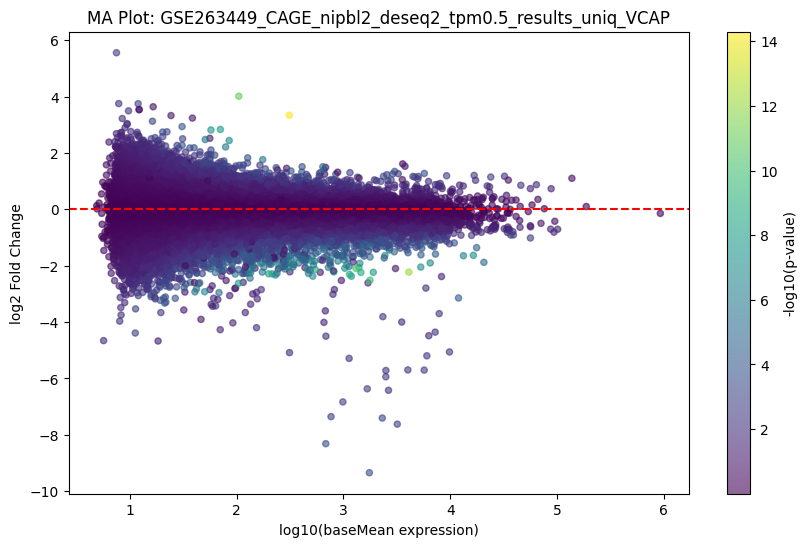


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_22RV1...


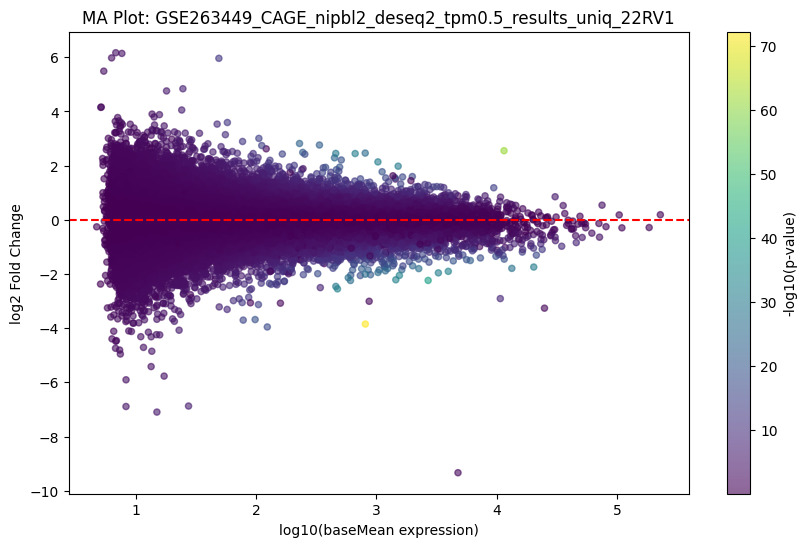


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_H358...


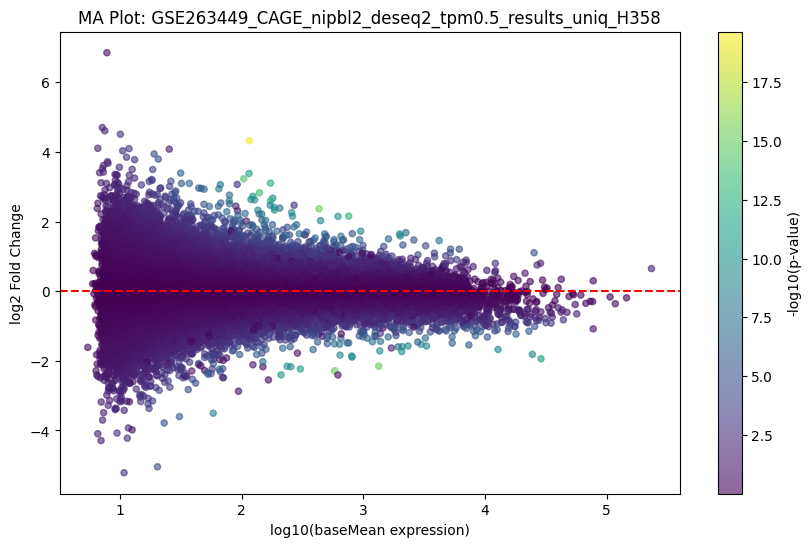


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_H2228...


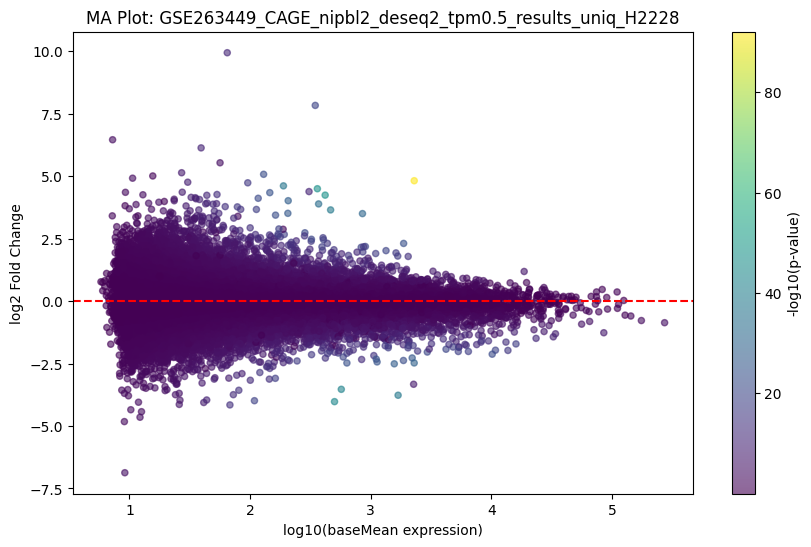


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_SW620...


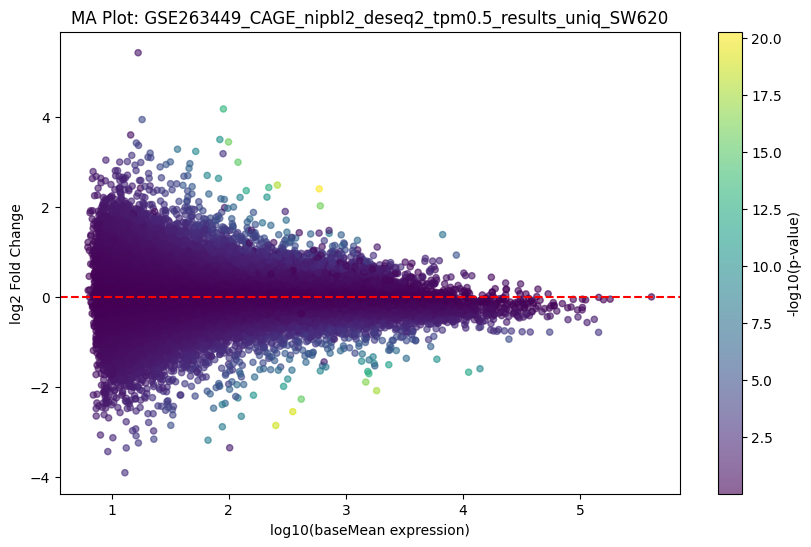


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_HCT116...


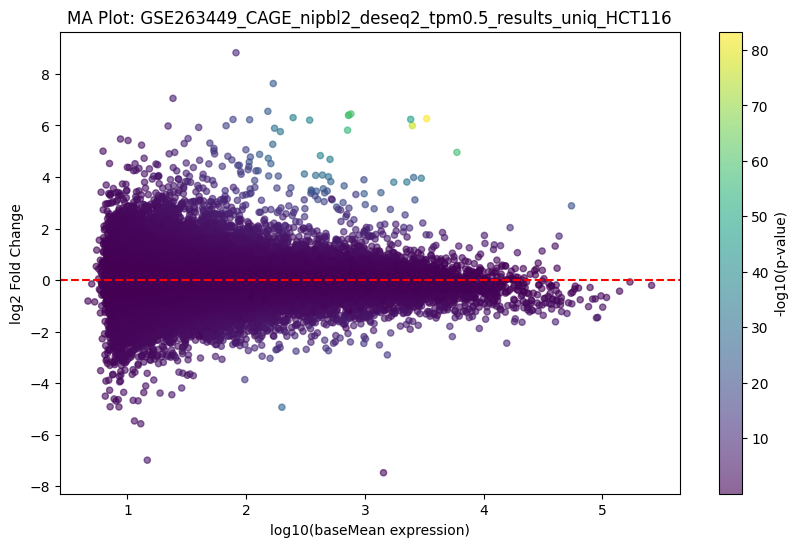


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_CAMA1...


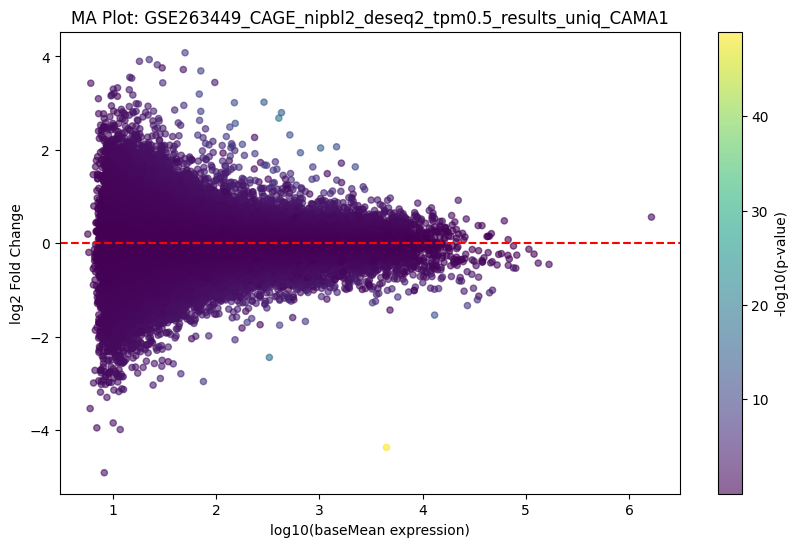


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_A549...


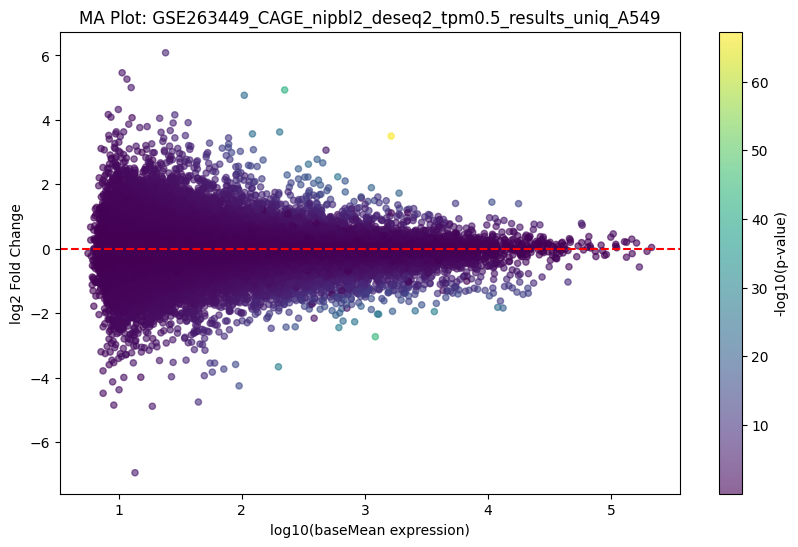


Showing plots for GSE263449_CAGE_nipbl2_deseq2_tpm0.5_results_uniq_C106...


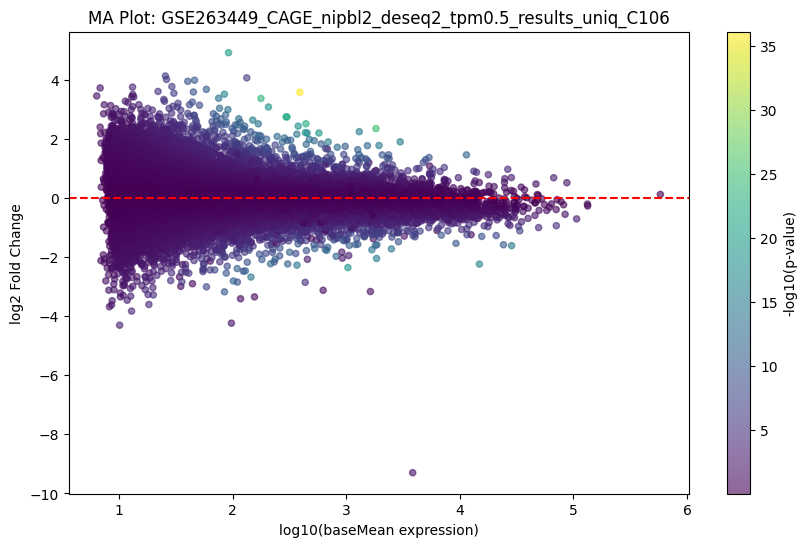

In [3]:
for cell_line, df in data.items():
    print(f"\nShowing plots for {cell_line}...")
    
    # 1. MA Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(
        x=np.log10(df['baseMean']),
        y=df['log2FoldChange'],
        c=-np.log10(df['pvalue']),
        cmap='viridis',
        alpha=0.6,
        s=20
    )
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('log10(baseMean expression)')
    plt.ylabel('log2 Fold Change')
    plt.title(f'MA Plot: {cell_line}')
    plt.colorbar(label='-log10(p-value)')
    plt.show()

## Volcano Plot: Significance vs Fold Change

**Volcano plots** visualize:
- X-axis: log2 fold change (magnitude of change)
- Y-axis: -log10 p-value (significance)
- Red = statistically significant genes (FDR < 0.05)

Ideal for identifying strongly affected genes.

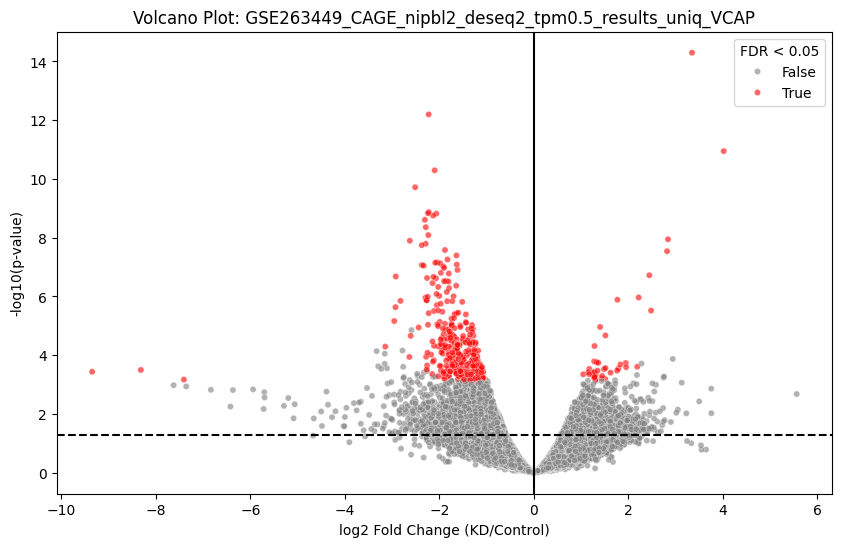

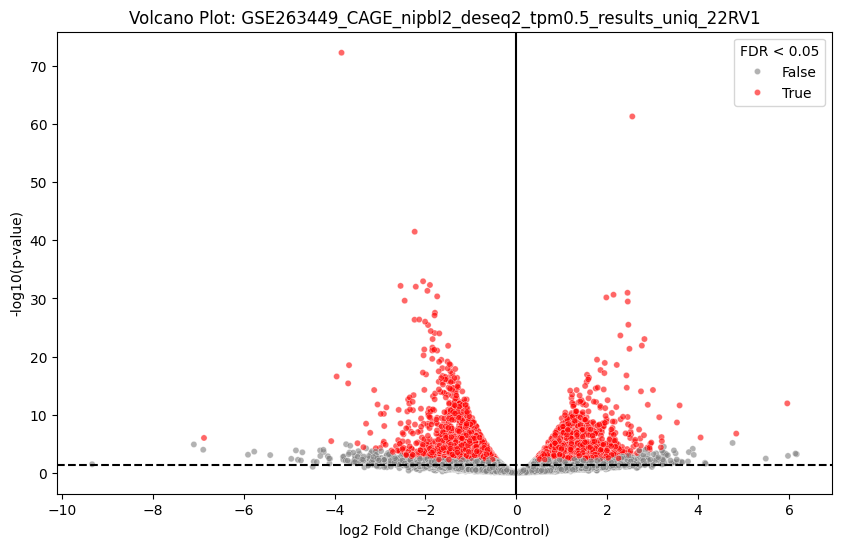

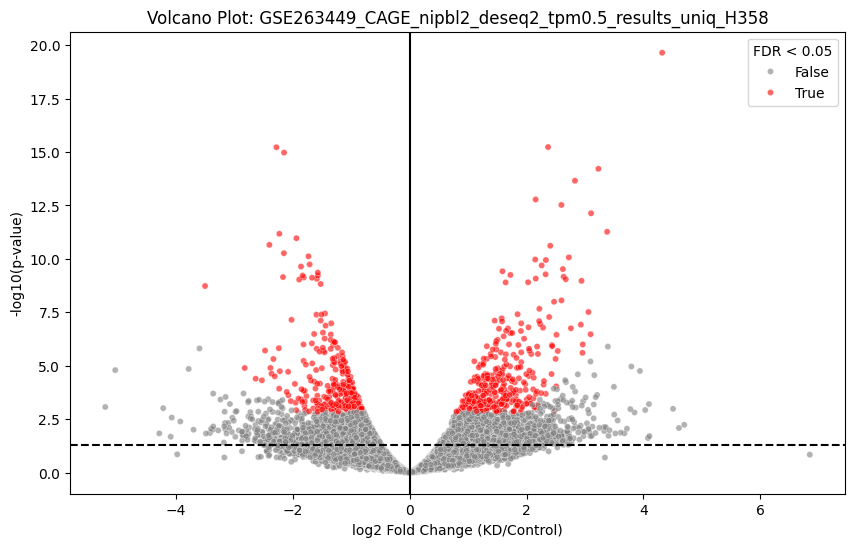

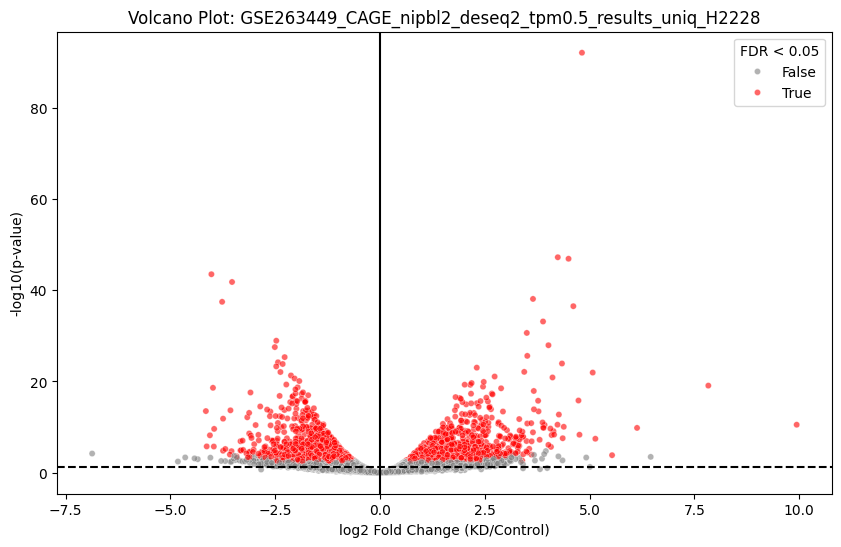

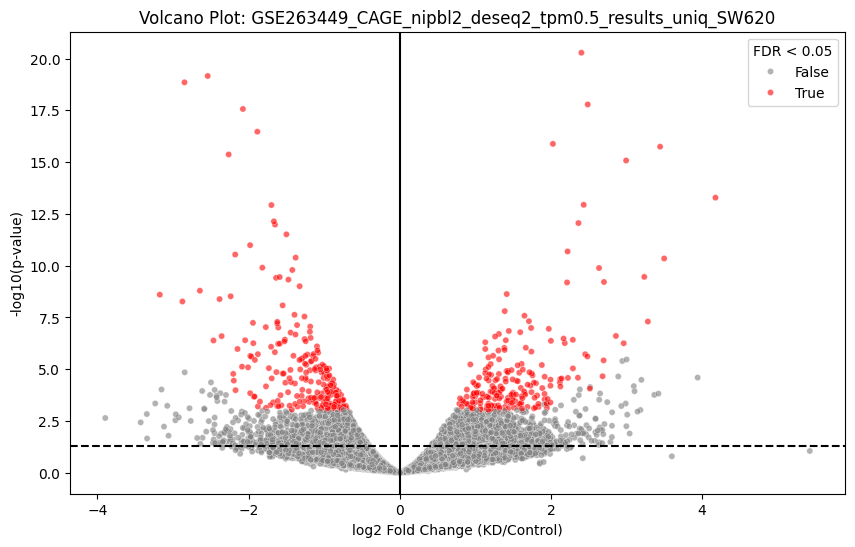

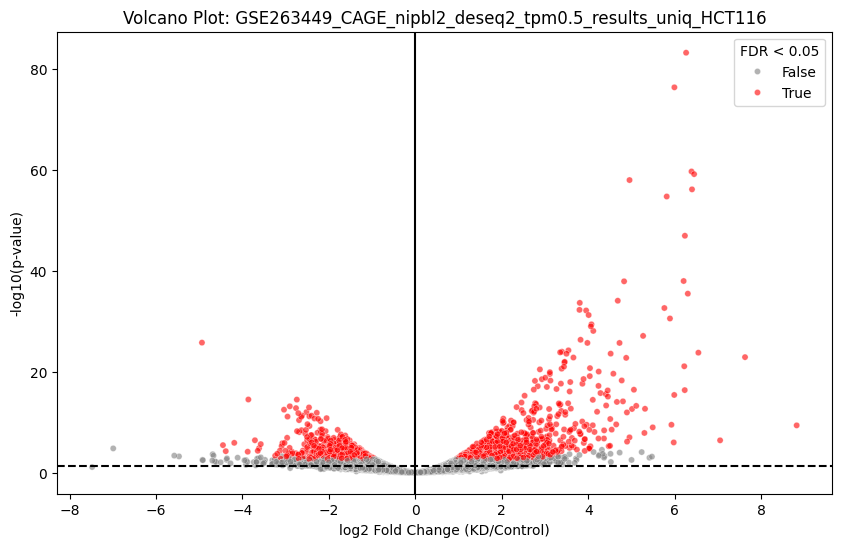

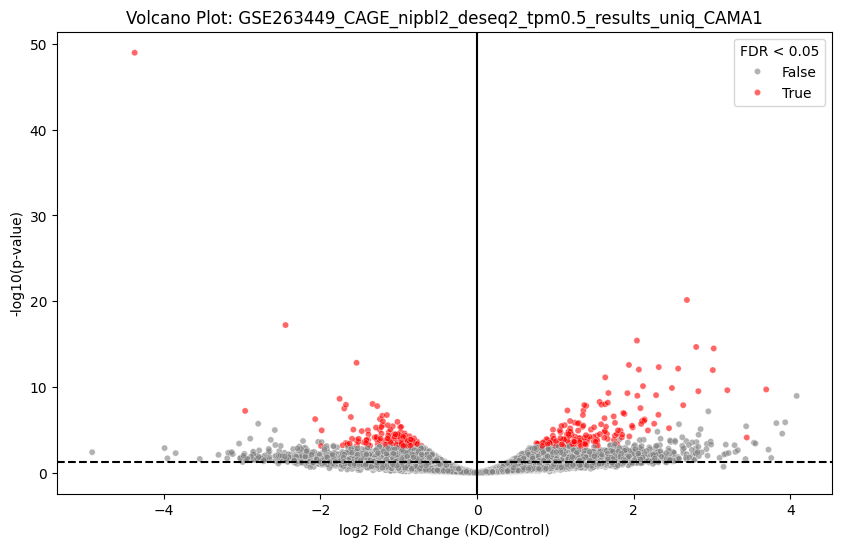

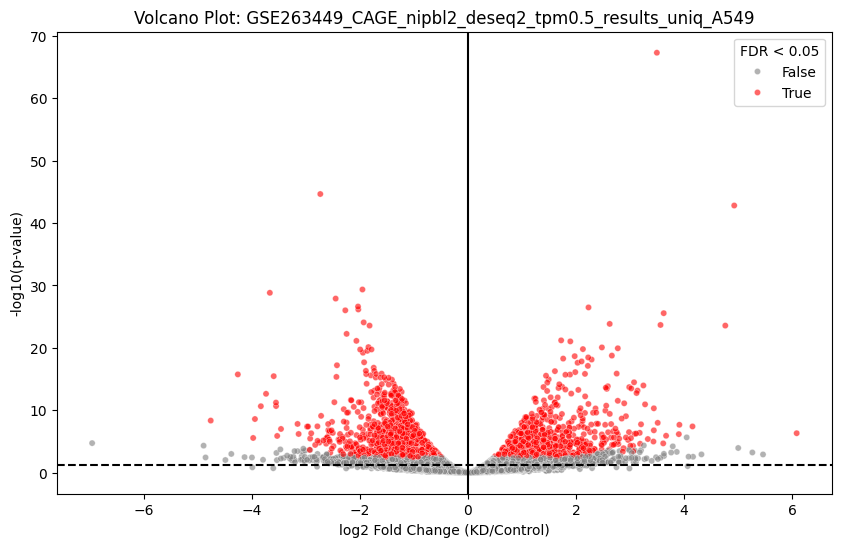

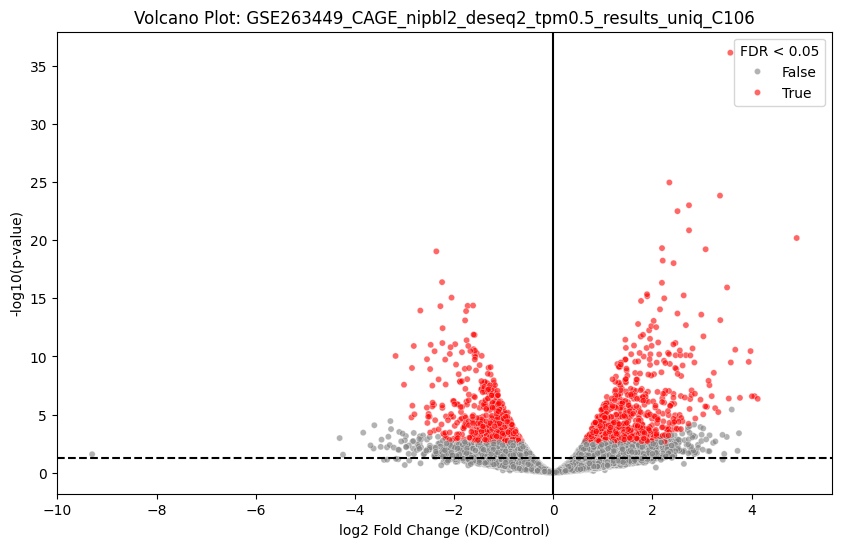

In [4]:
for cell_line, df in data.items():
    plt.figure(figsize=(10, 6))
    significant = df['padj'] < 0.05
    sns.scatterplot(
        x=df['log2FoldChange'],
        y=-np.log10(df['pvalue']),
        hue=significant,
        palette={True: 'red', False: 'grey'},
        alpha=0.6,
        s=20
    )
    plt.axhline(-np.log10(0.05), color='black', linestyle='--')
    plt.axvline(0, color='black')
    plt.xlabel('log2 Fold Change (KD/Control)')
    plt.ylabel('-log10(p-value)')
    plt.title(f'Volcano Plot: {cell_line}')
    plt.legend(title='FDR < 0.05')
    plt.show()

## Top 20 Differential TSSs

Bar plots of the **top 20 significantly differentially expressed TSSs** by lowest adjusted p-values. Helps prioritize the most impactful genes for further analysis.

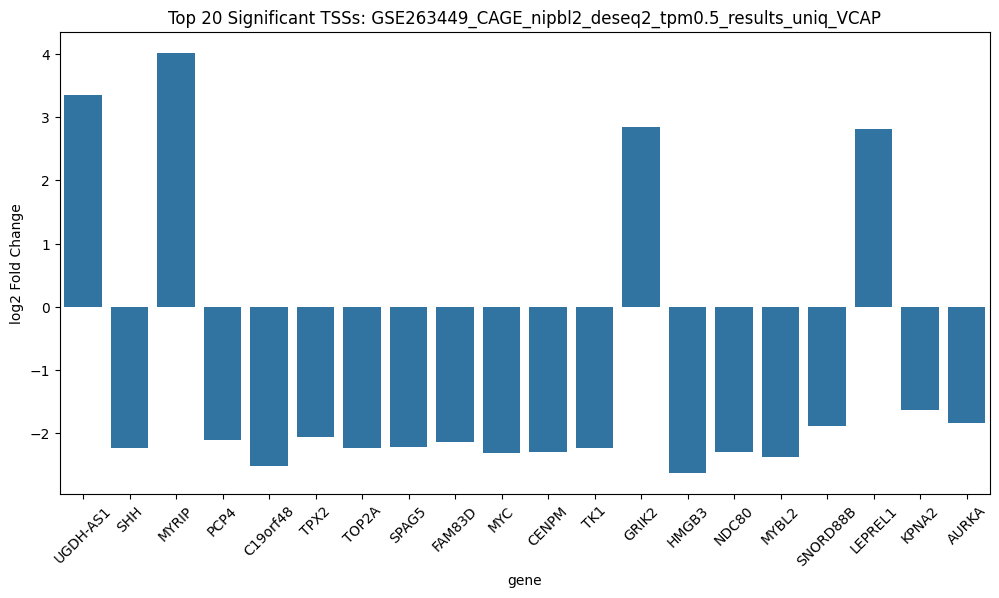

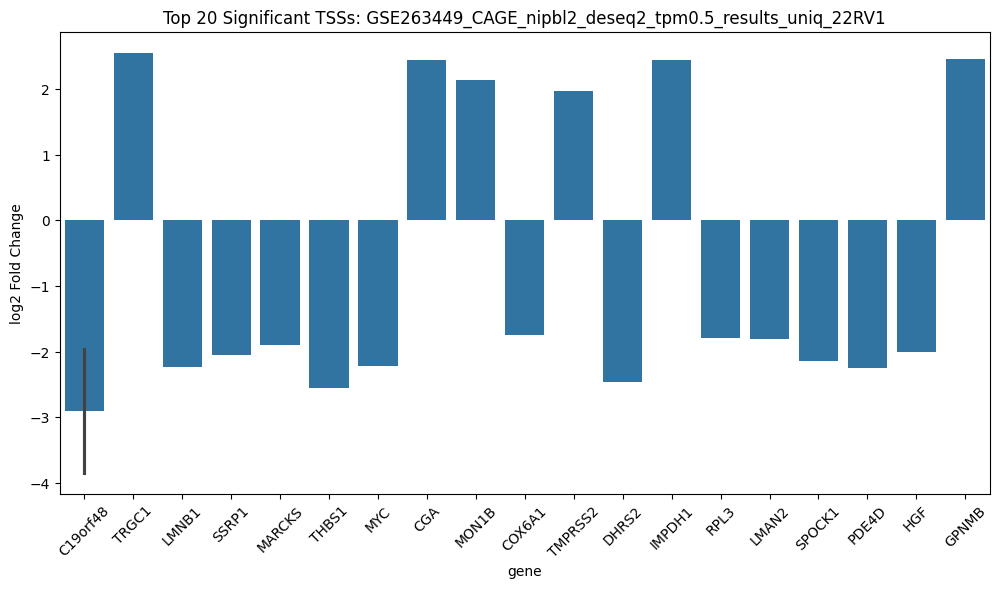

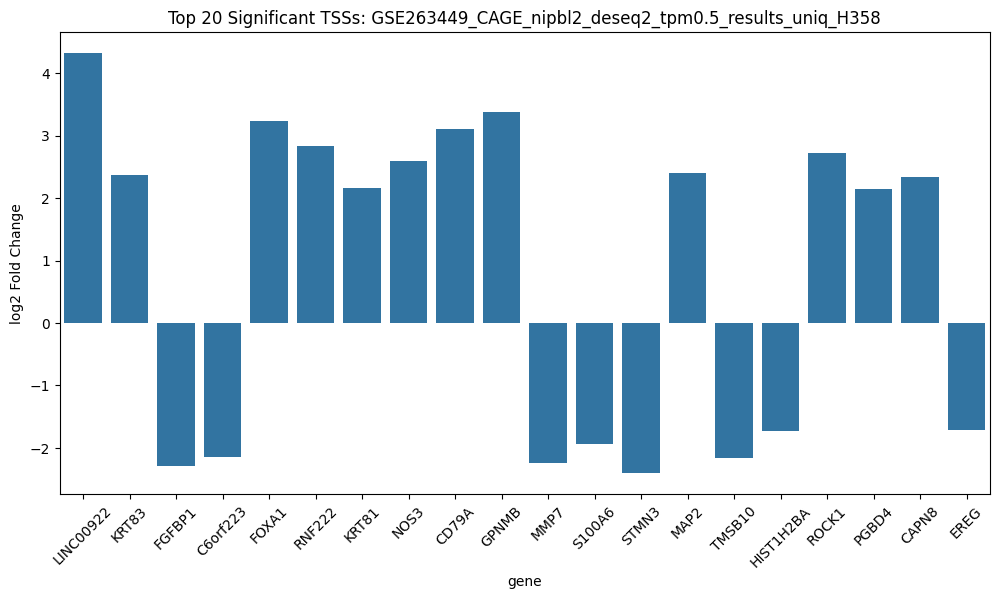

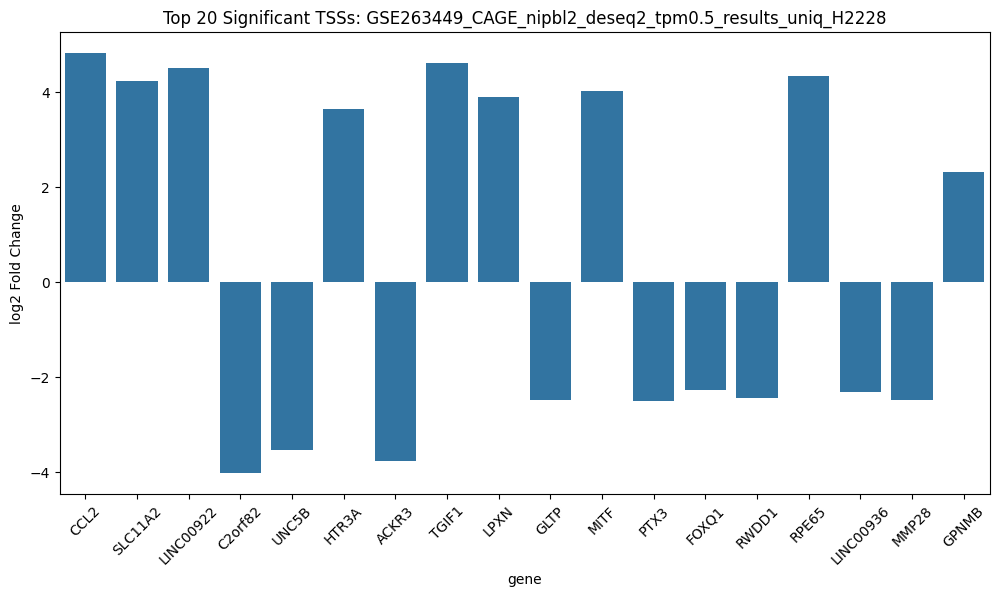

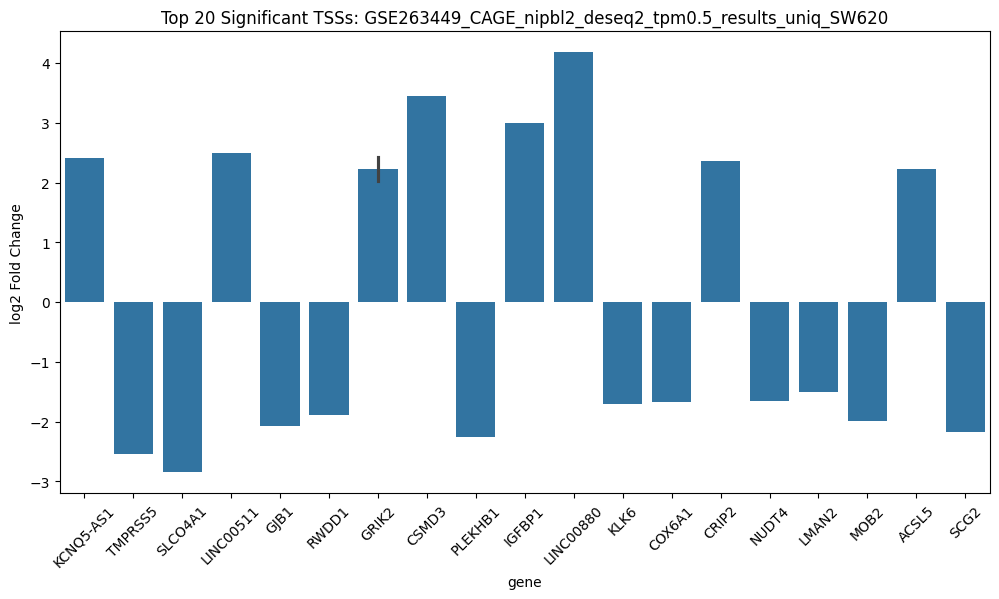

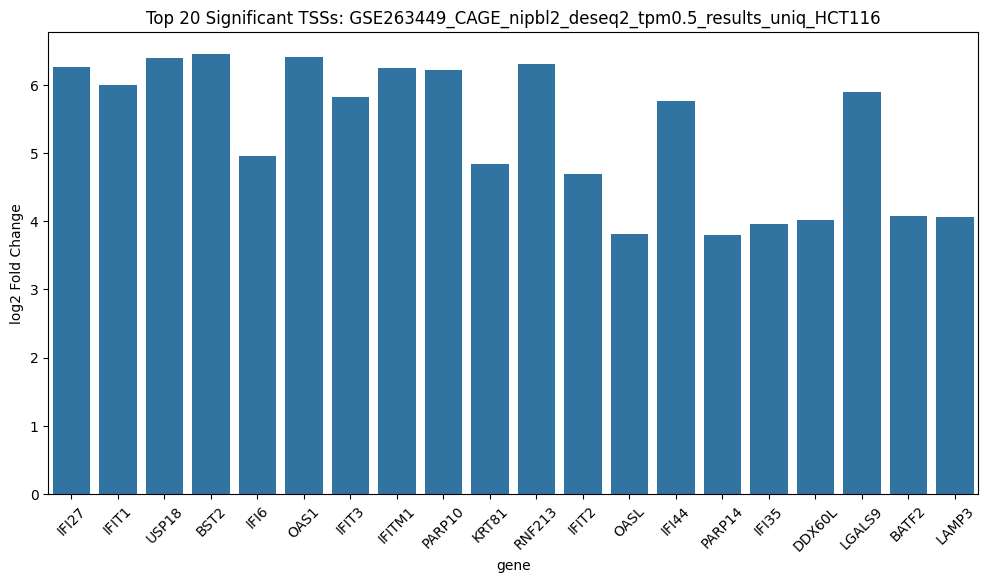

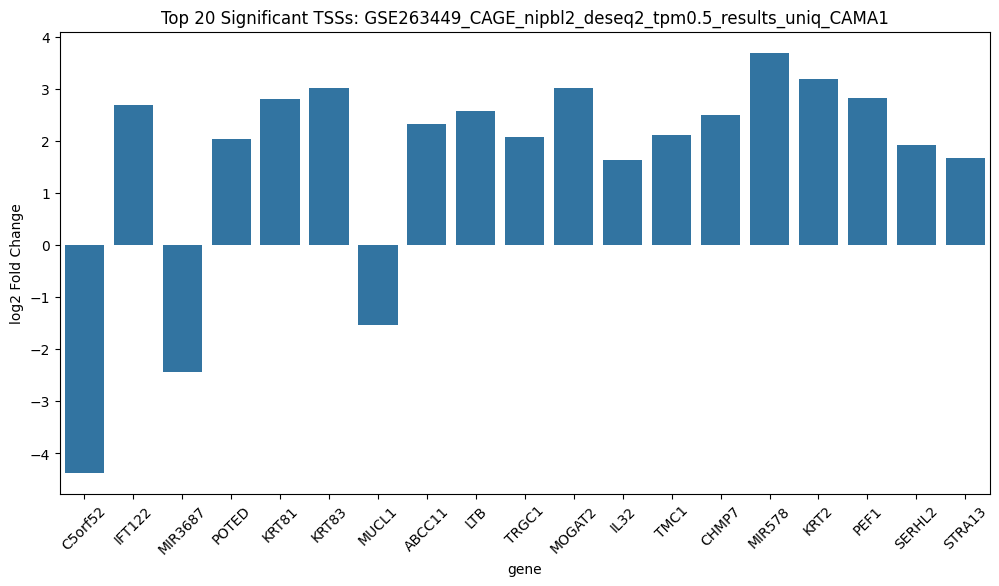

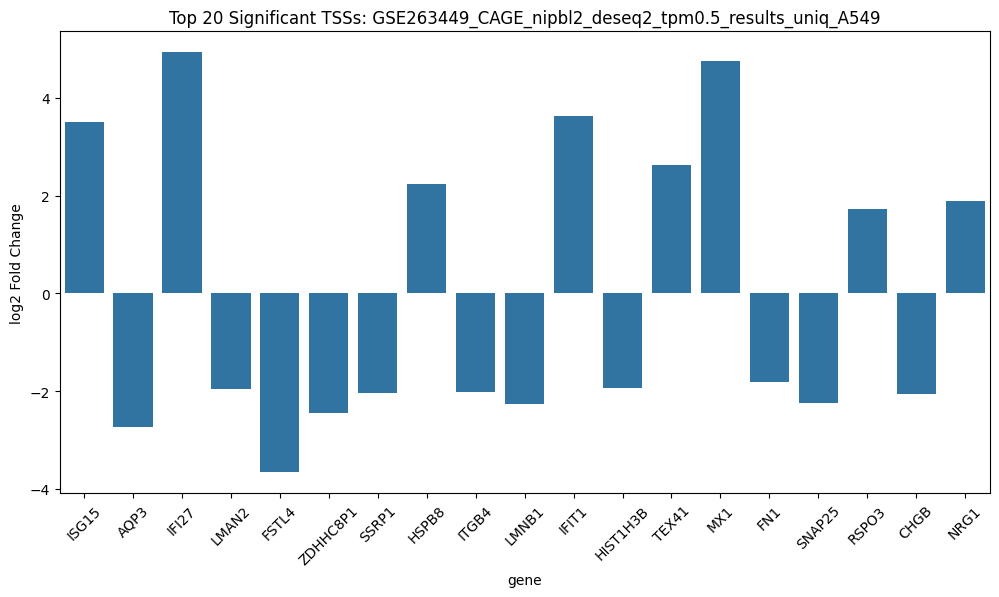

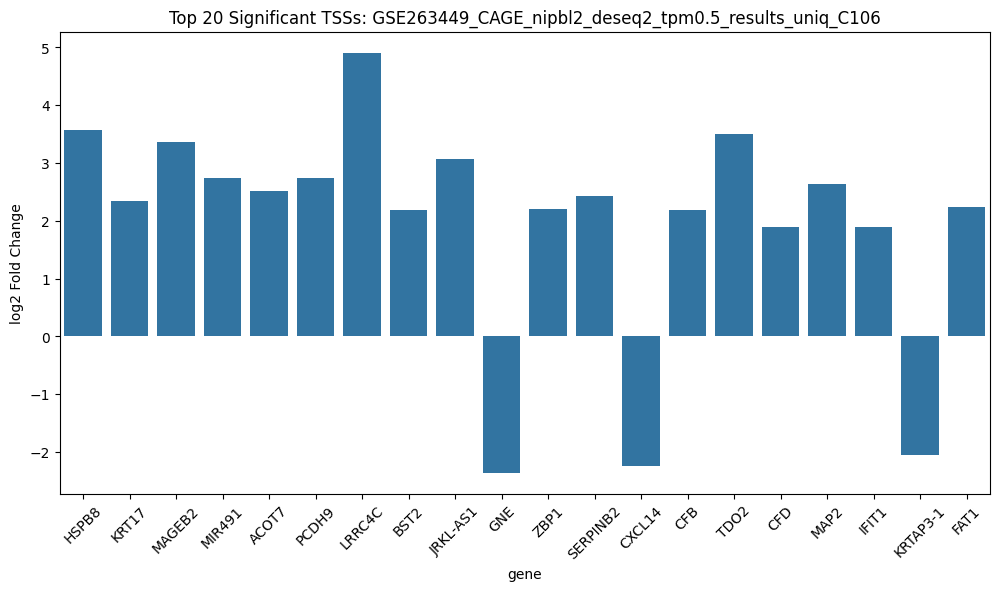

In [5]:
for cell_line, df in data.items():
    significant = df['padj'] < 0.05
    if significant.any():
        plt.figure(figsize=(12, 6))
        top_tss = df[significant].sort_values('padj').head(20)
        sns.barplot(x='gene', y='log2FoldChange', data=top_tss)
        plt.xticks(rotation=45)
        plt.title(f'Top 20 Significant TSSs: {cell_line}')
        plt.ylabel('log2 Fold Change')
        plt.show()
    else:
        print(f"No significant TSSs found for {cell_line}")

## Chromosome-wise Strip Plot

Displays TSSs with significant changes (FDR < 0.05) across chromosomes. Useful for spotting chromosome-level patterns or outliers.

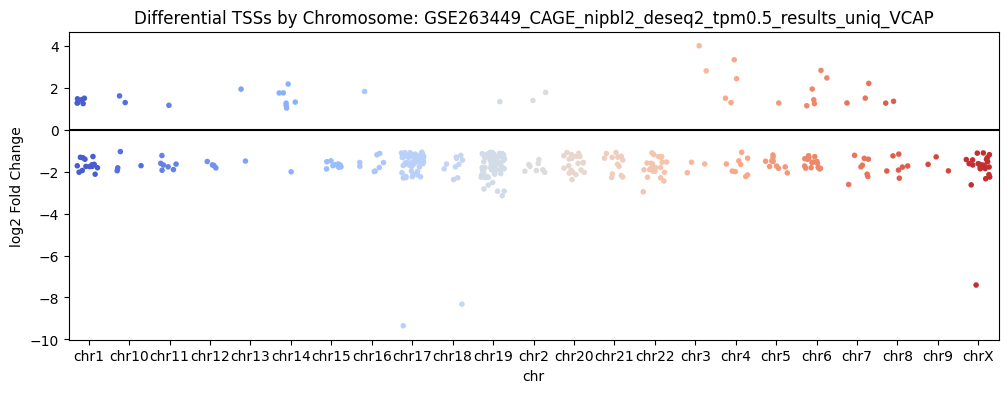

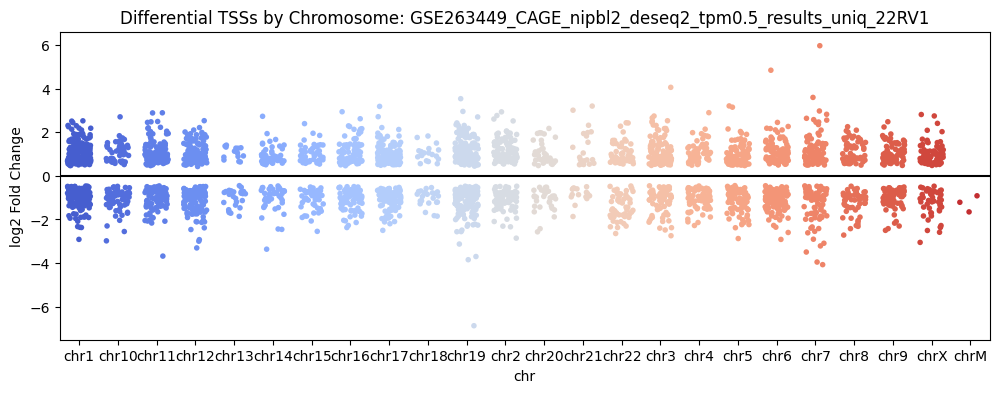

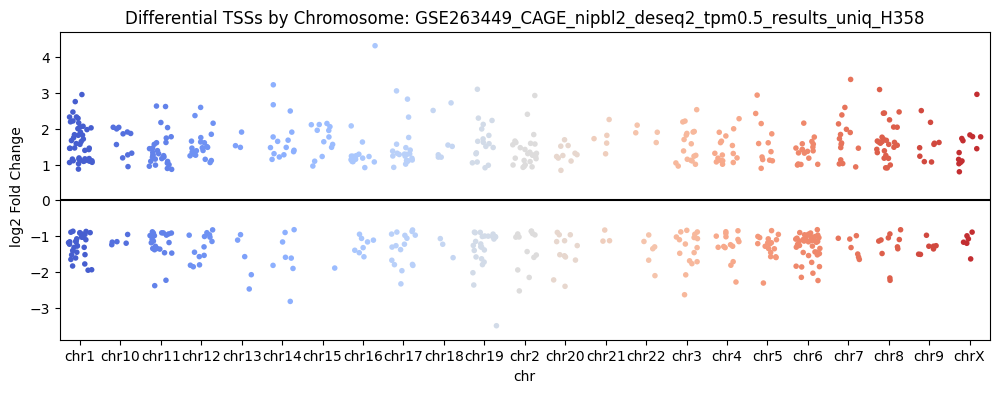

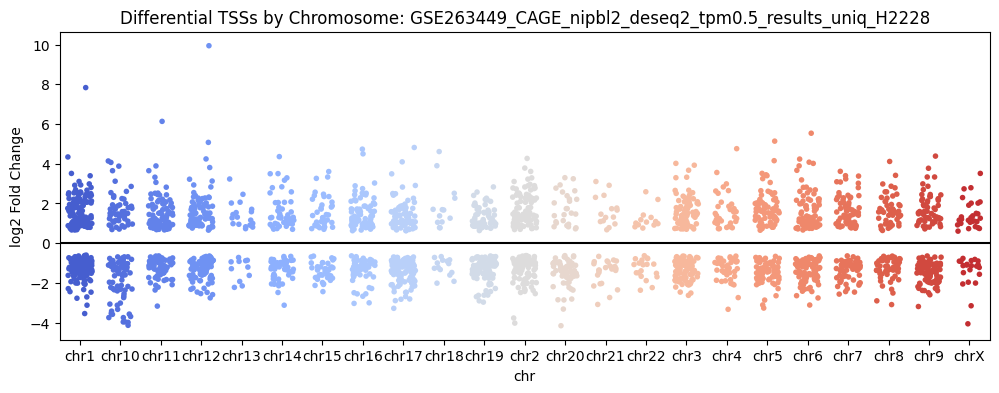

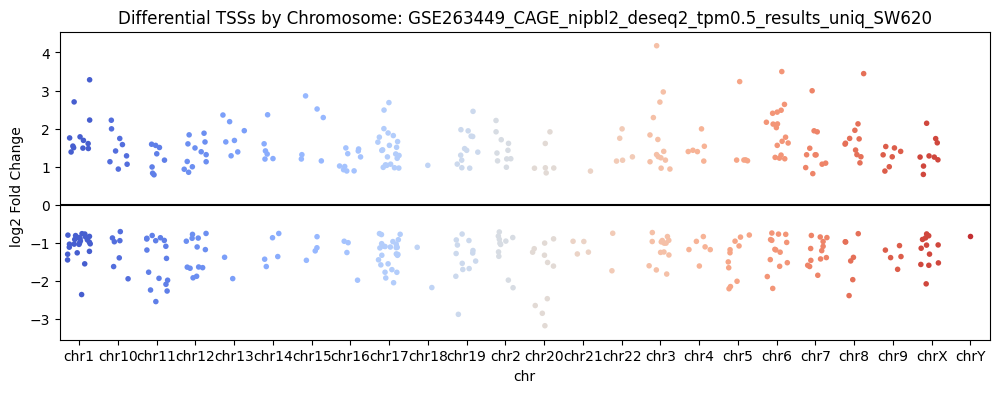

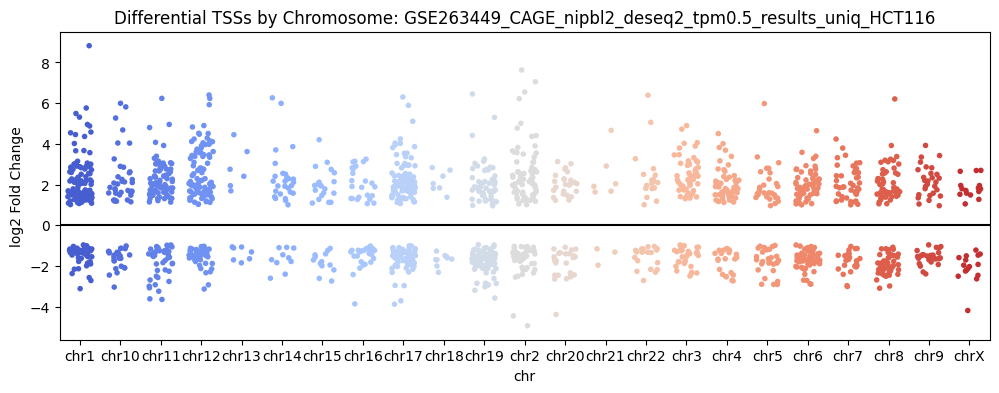

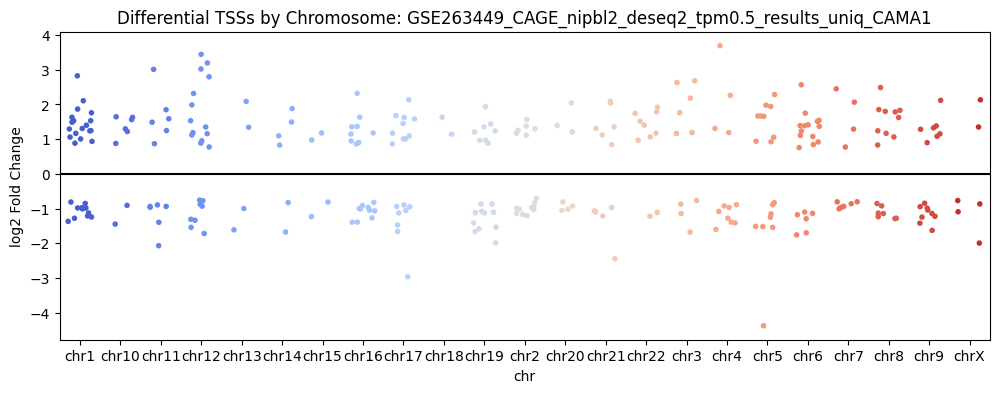

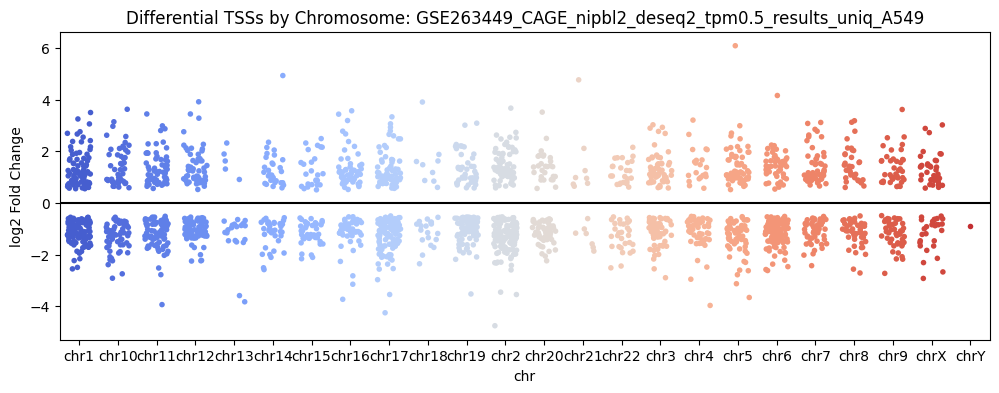

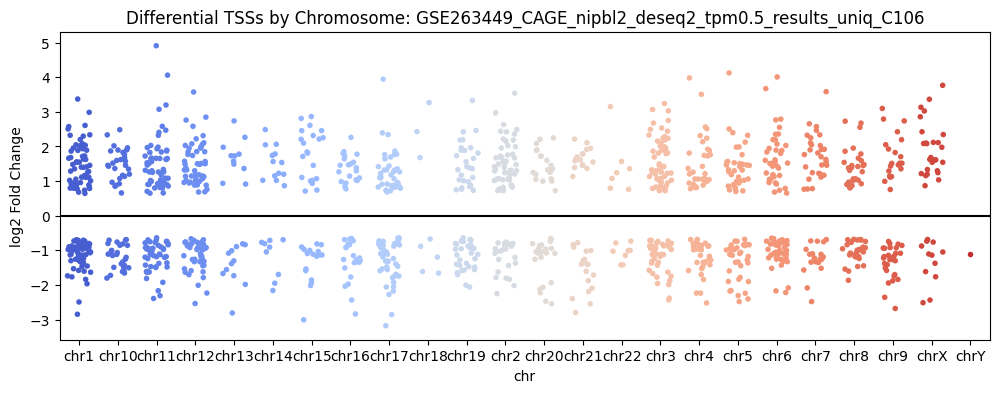

In [6]:
for cell_line, df in data.items():
    significant = df['padj'] < 0.05
    if significant.any():
        plt.figure(figsize=(12, 4))
        sns.stripplot(
            x='chr',
            y='log2FoldChange',
            data=df[significant],
            hue='chr',
            palette="coolwarm",
            jitter=0.3,
            size=4,
            legend=False
        )
        plt.axhline(0, color='black')
        plt.title(f'Differential TSSs by Chromosome: {cell_line}')
        plt.ylabel('log2 Fold Change')
        plt.show()
    else:
        print(f"No significant TSSs for chromosome plot in {cell_line}")

## Density Plot of Fold Changes

Plots the **distribution of log2 fold changes** per cell line, enabling quick comparison of overall up/down regulation trends between conditions.

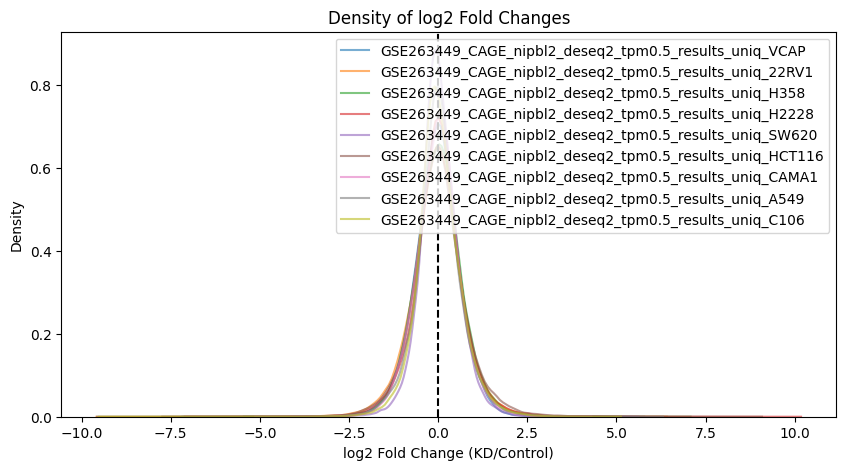

In [7]:
plt.figure(figsize=(10, 5))
for cell_line, df in data.items():
    sns.kdeplot(df['log2FoldChange'], label=cell_line, alpha=0.6)
plt.axvline(0, color='black', linestyle='--')
plt.title('Density of log2 Fold Changes')
plt.xlabel('log2 Fold Change (KD/Control)')
plt.ylabel('Density')
plt.legend()
plt.show()

## Boxplot: log2 Fold Change by Chromosome

A boxplot summarizing fold change distributions for each chromosome. Offers an overview of expression dynamics genome-wide.

/tmp/ipykernel_11137/3420893652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


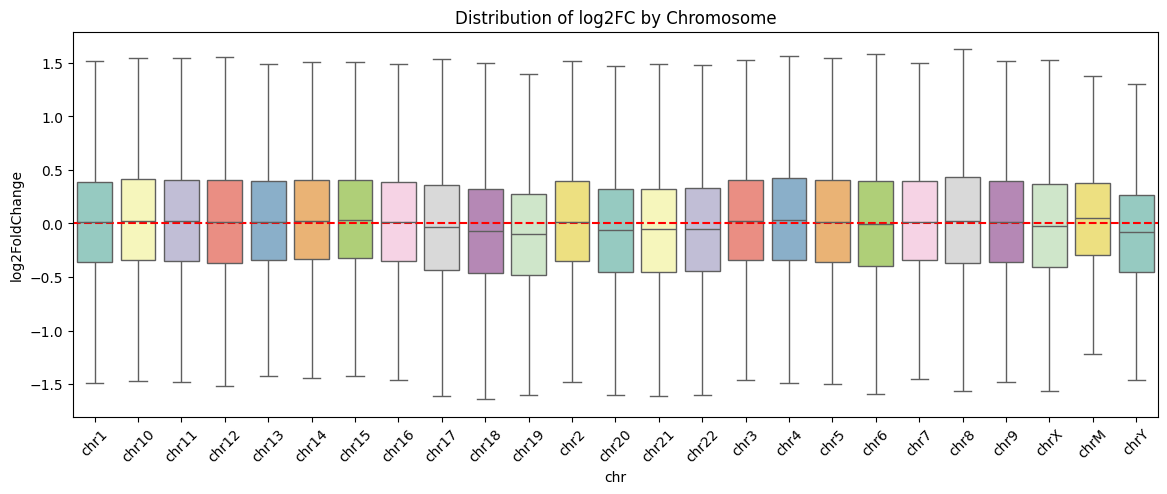

In [8]:
plt.figure(figsize=(14, 5))
sns.boxplot(
    x='chr',
    y='log2FoldChange',
    data=pd.concat(data.values()),
    showfliers=False,
    palette='Set3'
)
plt.axhline(0, color='red', linestyle='--')
plt.title('Distribution of log2FC by Chromosome')
plt.xticks(rotation=45)
plt.show()

## Correlation Matrix Between Cell Lines

Calculates **Pearson correlation** between fold changes of different cell lines. Helps assess similarity of KD effects across different cellular contexts.

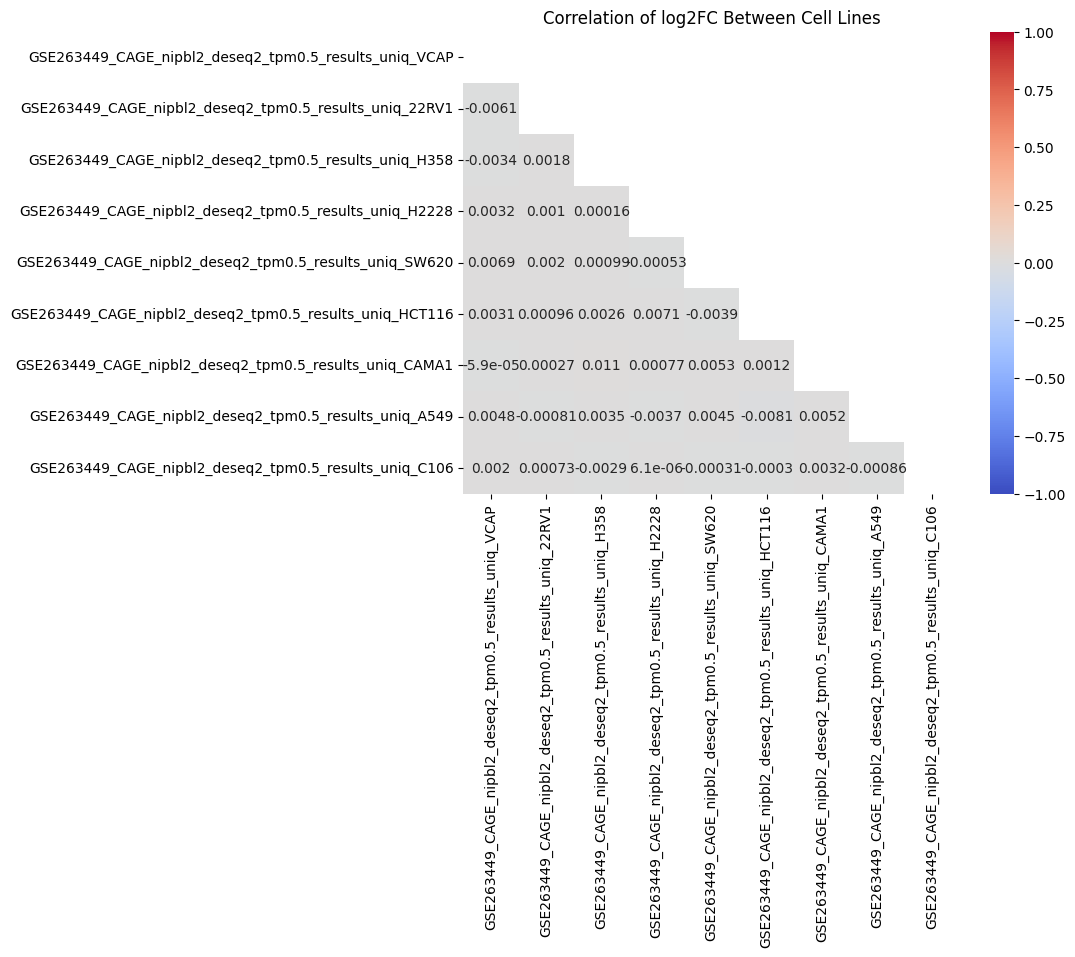

In [9]:
log2fc_matrix = pd.DataFrame({
    cell_line: df['log2FoldChange'] 
    for cell_line, df in data.items()
}).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    log2fc_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(log2fc_matrix))
)
plt.title('Correlation of log2FC Between Cell Lines')
plt.show()

## GO Enrichment Bubble Plot

Runs **Gene Ontology (GO) enrichment** using `gseapy` to identify biological processes overrepresented among significant genes. Larger and darker bubbles = stronger enrichment.


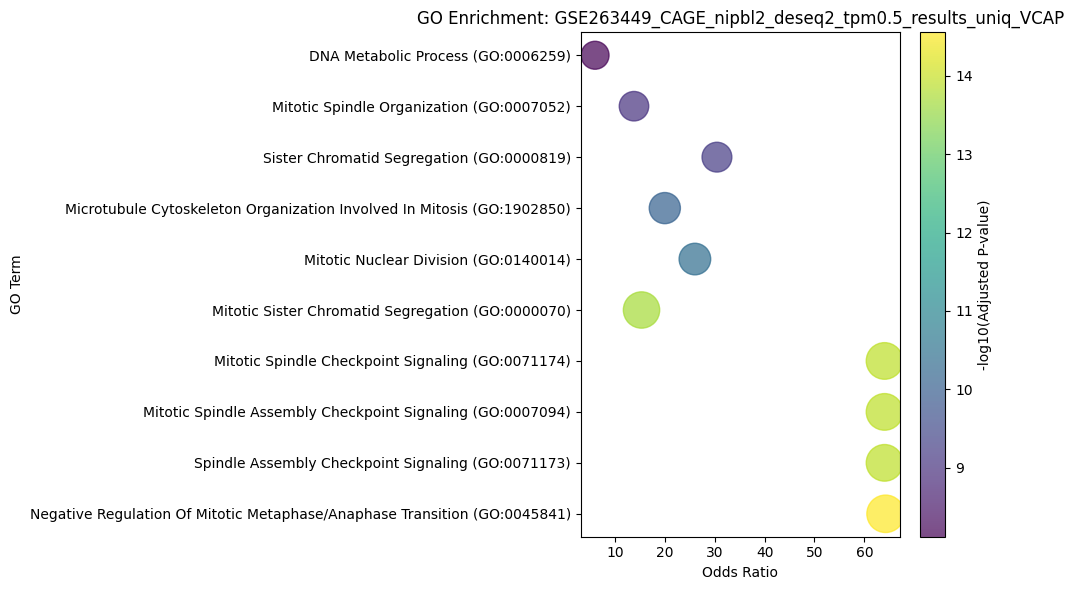

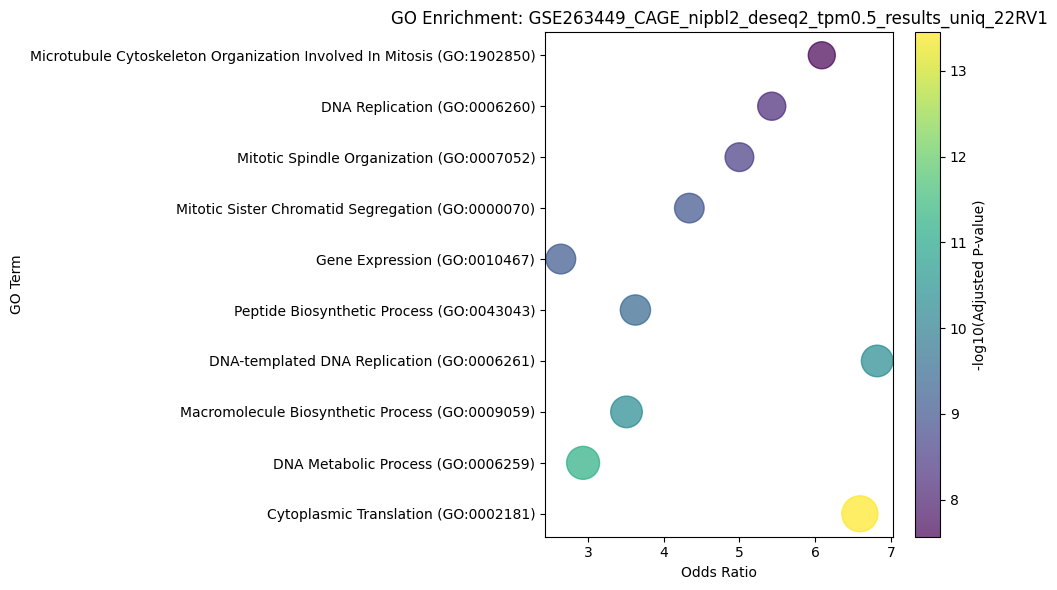

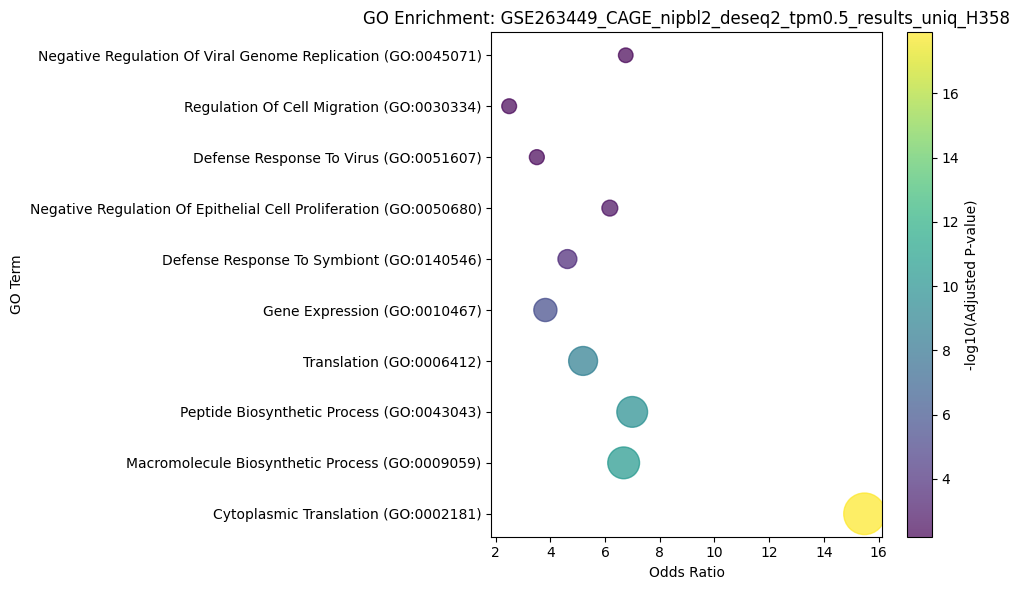

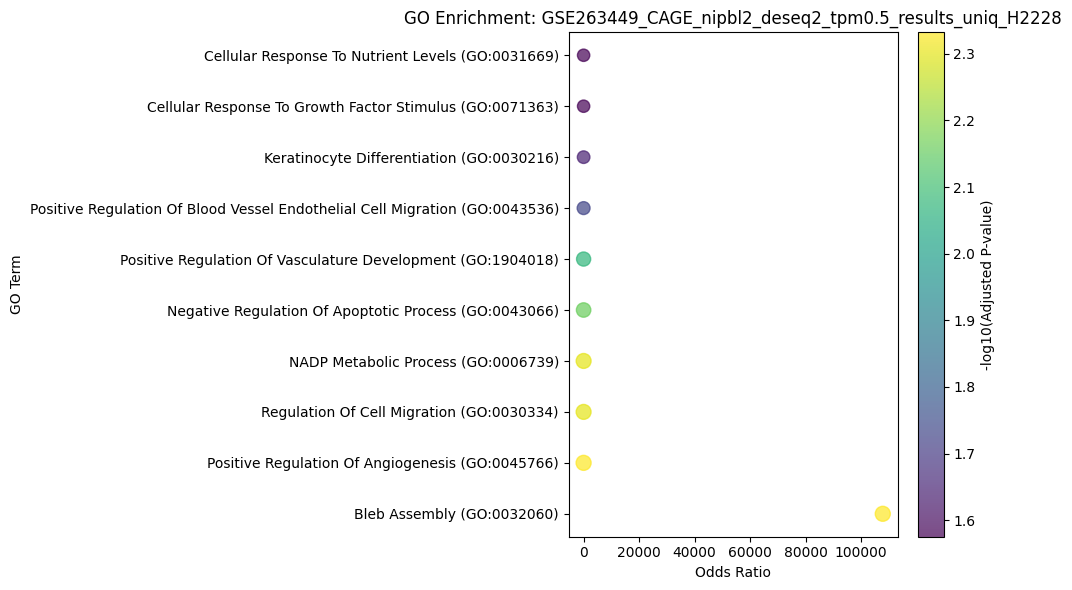

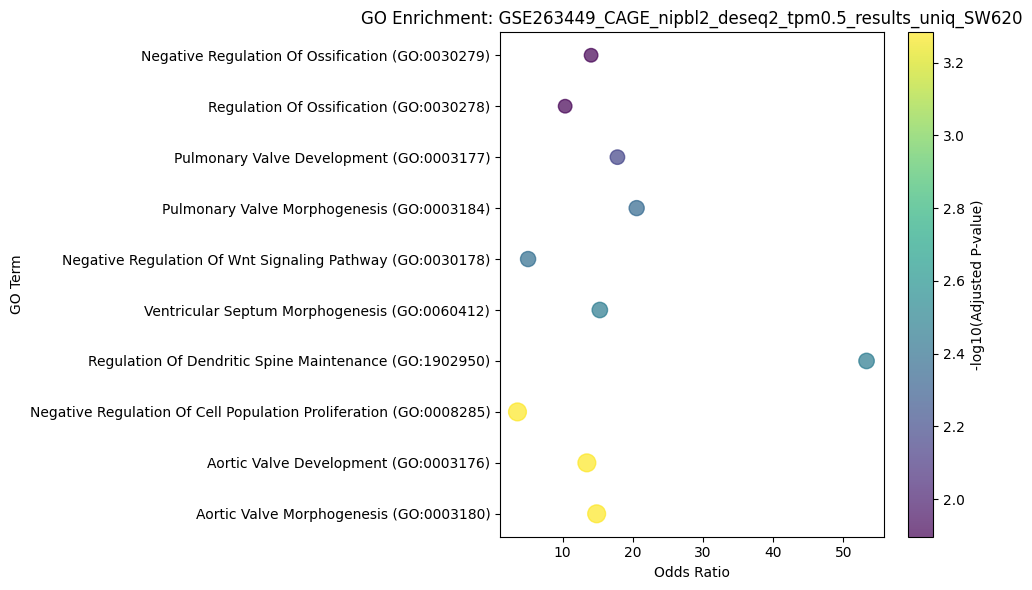

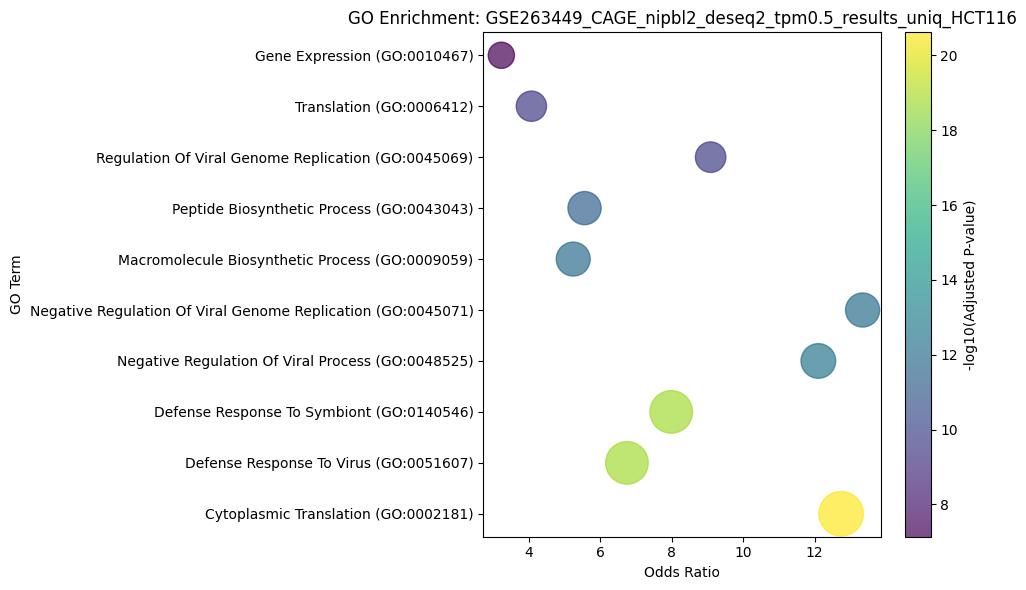

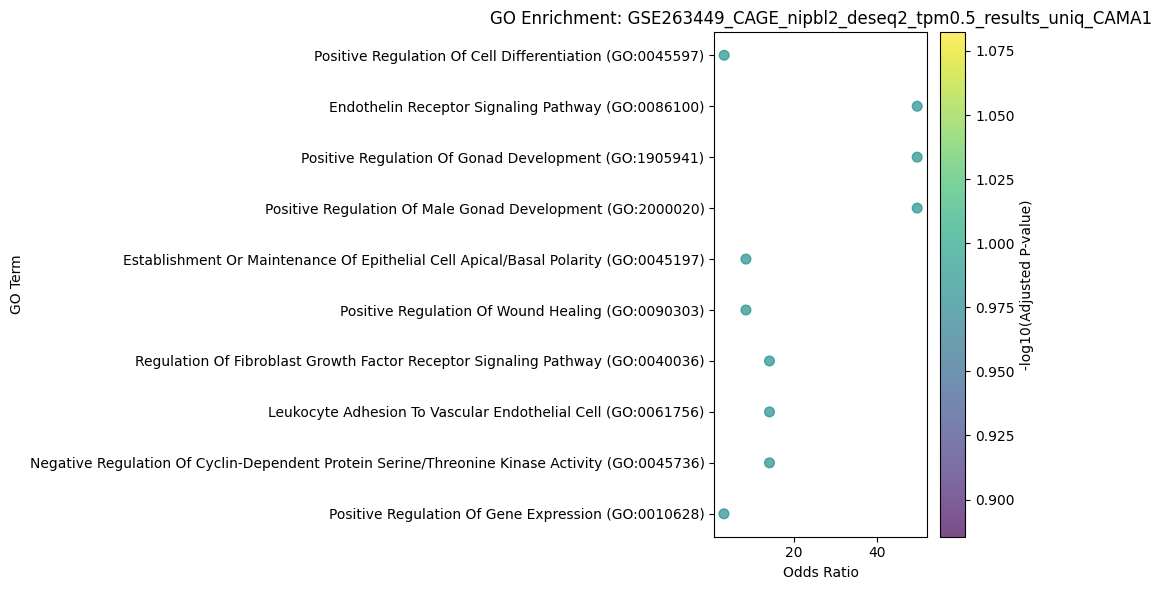

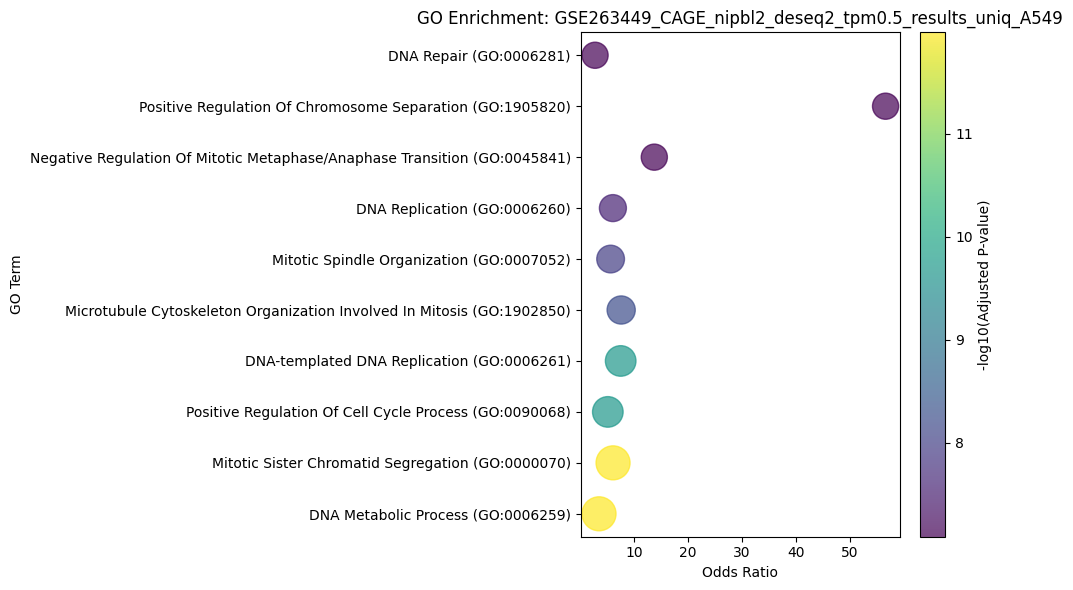

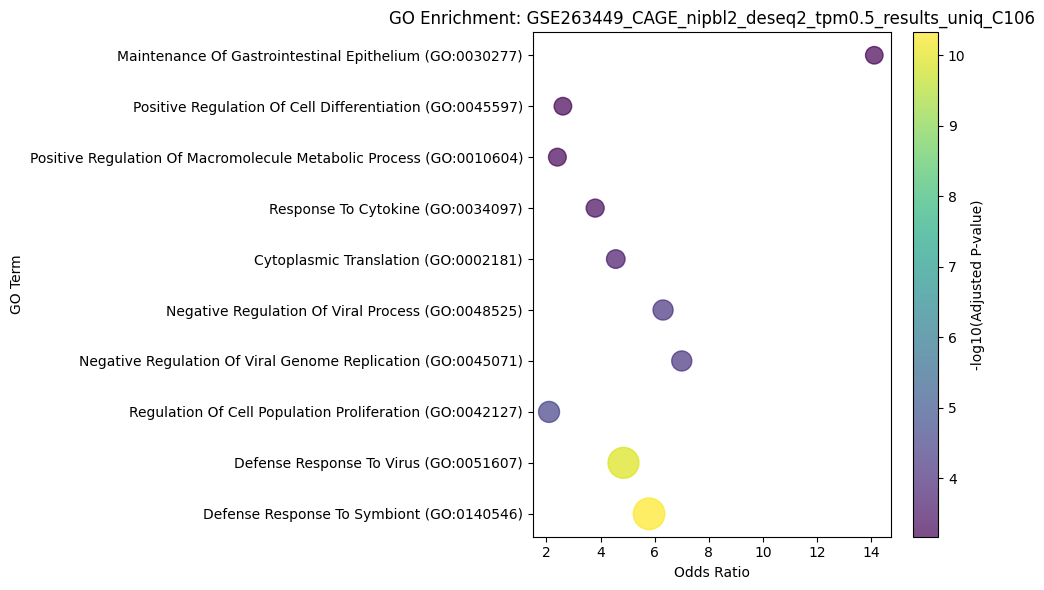

In [10]:
from gseapy import enrichr
import numpy as np
import matplotlib.pyplot as plt

for cell_line, df in data.items():
    significant_genes = df[df['padj'] < 0.05]['gene'].dropna().unique()
    
    if len(significant_genes) > 0:
        enr = enrichr(
            gene_list=significant_genes.tolist(),
            gene_sets=['GO_Biological_Process_2023'],
            organism='human'
        )
        
        plot_data = enr.results.sort_values('Adjusted P-value').head(10)
        plot_data['-log10(padj)'] = -np.log10(plot_data['Adjusted P-value'])
        
        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(
            x=plot_data['Odds Ratio'],
            y=plot_data['Term'],
            s=plot_data['-log10(padj)']*50,
            c=plot_data['-log10(padj)'],
            cmap='viridis',
            alpha=0.7
        )
        
        plt.colorbar(scatter, label='-log10(Adjusted P-value)')
        plt.title(f'GO Enrichment: {cell_line}')
        plt.xlabel('Odds Ratio')
        plt.ylabel('GO Term')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No significant genes for GO enrichment in {cell_line}")

## Interactive Volcano Plots

Generates interactive volcano plots using `plotly`, allowing users to hover over points to view gene and location metadata. Results are also saved as an HTML file.


In [ ]:
import plotly.express as px
from IPython.display import display, HTML

all_plots_html = []

for cell_line, df in data.items():
    df_plot = df.copy()
    df_plot['-log10(padj)'] = -np.log10(df['padj'].replace(0, 1e-300))  # Handle p=0 cases
    df_plot['significant'] = df['padj'] < 0.05
    df_plot['gene_info'] = df['gene'] + ' (' + df['chr'] + ':' + df['start'].astype(str) + ')'
    
    fig = px.scatter(
        df_plot,
        x='log2FoldChange',
        y='-log10(padj)',
        color='significant',
        color_discrete_map={True: 'red', False: 'gray'},
        hover_data={
            'gene': True,
            'chr': True,
            'start': True,
            'log2FoldChange': ':.2f',
            'padj': ':.2e'
        },
        title=f'{cell_line}: NIPBL KD vs Control (FDR < 0.05)',
        labels={
            'log2FoldChange': 'log2 Fold Change',
            '-log10(padj)': '-log10(Adjusted p-value)'
        },
        width=800,
        height=600
    )
    
    fig.add_hline(
        y=-np.log10(0.05),
        line_dash="dash",
        line_color="black",
        annotation_text="FDR = 0.05", 
        annotation_position="top right"
    )
    
    fig.update_layout(
        hovermode='closest',
        showlegend=True,
        legend_title_text='Significant'
    )
    
    html_str = fig.to_html(full_html=False)
    all_plots_html.append(html_str)
    
    display(HTML(f"<h3>{cell_line}</h3>"))
    fig.show()

with open('all_volcano_plots.html', 'w') as f:
    f.write("<html><body>" + "\n".join(all_plots_html) + "</body></html>")

This notebook enables biological interpretation of CAGE-seq data through:
- Statistical visualization (MA, Volcano, Boxplot)
- Chromosome-level analysis
- Functional enrichment
- Interactive exploration